In [2]:
# Importing all the required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy
import os
import pickle
import librosa
import librosa.display
import IPython.display as ipd
from IPython.display import Audio
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential

In [4]:
# Reading the csv file
df = pd.read_csv("features_3_sec.csv")
df.head()


,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.0.wav,66149,0.335406,0.091048,0.130405,0.003521,1773.065032,167541.630869,1972.744388,117335.771563,...,39.687145,-3.241280,36.488243,0.722209,38.099152,-5.050335,33.618073,-0.243027,43.771767,blues
1,blues.00000.1.wav,66149,0.343065,0.086147,0.112699,0.001450,1816.693777,90525.690866,2010.051501,65671.875673,...,64.748276,-6.055294,40.677654,0.159015,51.264091,-2.837699,97.030830,5.784063,59.943081,blues
2,blues.00000.2.wav,66149,0.346815,0.092243,0.132003,0.004620,1788.539719,111407.437613,2084.565132,75124.921716,...,67.336563,-1.768610,28.348579,2.378768,45.717648,-1.938424,53.050835,2.517375,33.105122,blues
3,blues.00000.3.wav,66149,0.363639,0.086856,0.132565,0.002448,1655.289045,111952.284517,1960.039988,82913.639269,...,47.739452,-3.841155,28.337118,1.218588,34.770935,-3.580352,50.836224,3.630866,32.023678,blues
4,blues.00000.4.wav,66149,0.335579,0.088129,0.143289,0.001701,1630.656199,79667.267654,1948.503884,60204.020268,...,30.336359,0.664582,45.880913,1.689446,51.363583,-3.392489,26.738789,0.536961,29.146694,blues


In [6]:
df.dtypes

,0
filename,object
length,int64
chroma_stft_mean,float64
chroma_stft_var,float64
rms_mean,float64
rms_var,float64
spectral_centroid_mean,float64
spectral_centroid_var,float64
spectral_bandwidth_mean,float64
spectral_bandwidth_var,float64


In [11]:
df.shape

(9990, 59)

In [5]:
print(df.iloc[:,:-1])

               filename  length  chroma_stft_mean  chroma_stft_var  rms_mean  \
0     blues.00000.0.wav   66149          0.335406         0.091048  0.130405   
1     blues.00000.1.wav   66149          0.343065         0.086147  0.112699   
2     blues.00000.2.wav   66149          0.346815         0.092243  0.132003   
3     blues.00000.3.wav   66149          0.363639         0.086856  0.132565   
4     blues.00000.4.wav   66149          0.335579         0.088129  0.143289   
...                 ...     ...               ...              ...       ...   
9985   rock.00099.5.wav   66149          0.349126         0.080515  0.050019   
9986   rock.00099.6.wav   66149          0.372564         0.082626  0.057897   
9987   rock.00099.7.wav   66149          0.347481         0.089019  0.052403   
9988   rock.00099.8.wav   66149          0.387527         0.084815  0.066430   
9989   rock.00099.9.wav   66149          0.369293         0.086759  0.050524   

       rms_var  spectral_centroid_mean 

In [8]:
# Drop the column filename as it is no longer required for training
df=df.drop(labels="filename",axis=1)

# Standardise data

In [9]:
#scaling
from sklearn.preprocessing import StandardScaler
fit=StandardScaler()
X=fit.fit_transform(np.array(df.iloc[:,:-1],dtype=float))

In [10]:
X.shape

(9990, 58)

# PCA, Apply PCA on the *dataset*

In [14]:
# generate covariance matrix
C=(X.T @ X)/(X.shape[0]-1)

#eignedecomposition
[V, PC]=np.linalg.eig(C)

# sort eigenvectors based on eignevalues
sorted_indices=np.argsort(V)[::-1] # sort eigenvalues in descending order
sorted_PC=PC[:,sorted_indices] # sorted eigenvectors
sorted_V=V[sorted_indices] # sorted eignevalues

# only get the first 2 principle components
PC=PC[:,:2]
X_pca=X @ PC

In [15]:
X_pca.shape

(9990, 2)

Plot PCA on 2D graph

In [19]:
# Label Encoding - encod the categorical classes with numerical integer values for training

# Blues - 0
# Classical - 1
# Country - 2
# Disco - 3
# Hip-hop - 4
# Jazz - 5
# Metal - 6
# Pop - 7
# Reggae - 8
# Rock - 9

class_encod=df.iloc[:,-1]
converter=LabelEncoder()
y=converter.fit_transform(class_encod)
print(y)
print(class_encod)
print(y.shape)


[0 0 0 ... 9 9 9]
0       blues
1       blues
2       blues
3       blues
4       blues
        ...  
9985     rock
9986     rock
9987     rock
9988     rock
9989     rock
Name: label, Length: 9990, dtype: object
(9990,)


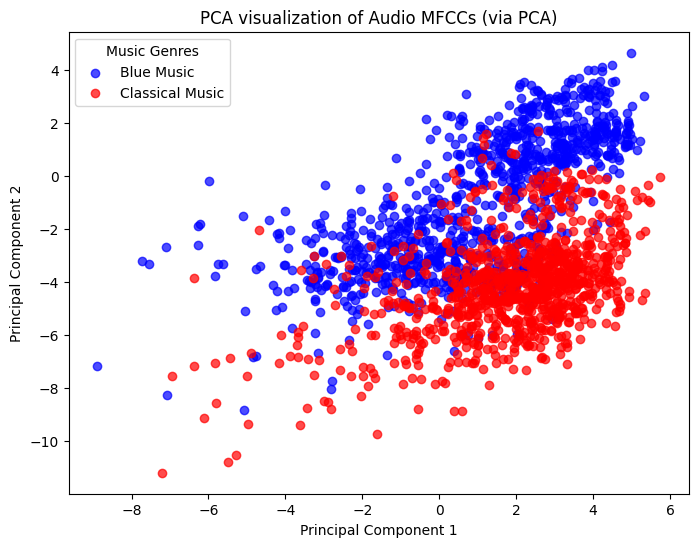

In [26]:
colors = ['blue', 'red',] # can assign more colors when more classes
class_labels=['Blue Music', 'Classical Music']

plt.figure(figsize=[8, 6])

for i in range(len(colors)):
  px=X_pca[:,0][y==i]
  py=X_pca[:,1][y==i]
  plt.scatter(px,py, c=colors[i], label=class_labels[i], alpha=0.7 )

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA visualization of Audio MFCCs (via PCA)')
plt.legend(title="Music Genres")
plt.show()

## TSNE, Plot TSNE for the data

In [27]:

from sklearn.manifold import TSNE

In [28]:
tsne=TSNE(n_components=2, perplexity=30, random_state=42, init='pca')
X_tsne=tsne.fit_transform(X) # or use X_pca for better performance

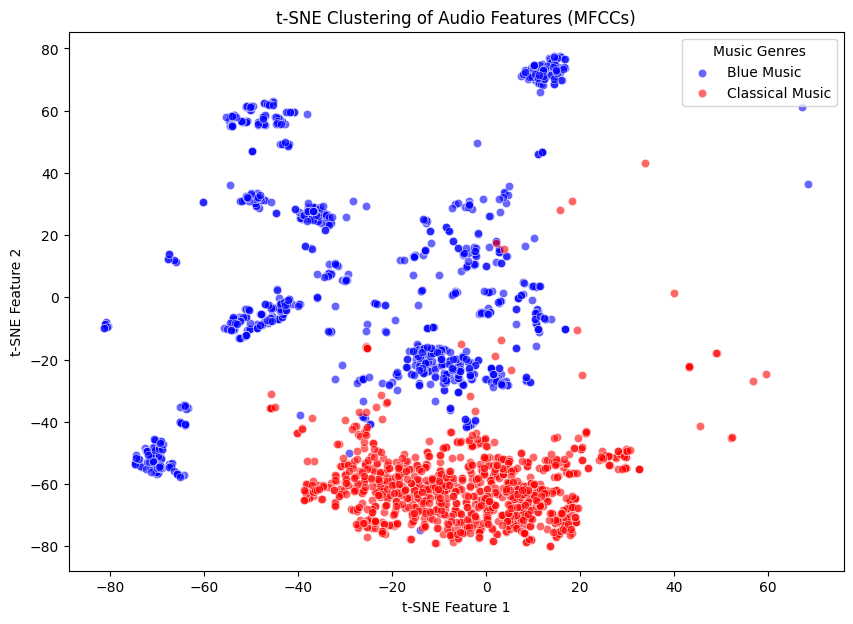

In [31]:
# 2. Define colors and labels
colors = ['blue', 'red']
class_labels = ['Blue Music', 'Classical Music']

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111)

# 3. Loop to plot each class separately for the legend
for i in range(len(colors)):
    # Mask to select only the points belonging to class 'i'
    mask = (y == i)

    ax.scatter(
        X_tsne[mask, 0],
        X_tsne[mask, 1],
        c=colors[i],
        label=class_labels[i],
        alpha=0.6,
        edgecolors='w', # White edge makes points pop on t-SNE
        linewidth=0.5
    )

# 4. Final Formatting
ax.set_xlabel('t-SNE Feature 1')
ax.set_ylabel('t-SNE Feature 2')
ax.set_title('t-SNE Clustering of Audio Features (MFCCs)')
ax.legend(title="Music Genres", loc='upper right')

plt.show()

In [33]:
X_tsne_2=tsne.fit_transform(X_pca) # or use X_pca for performance testing

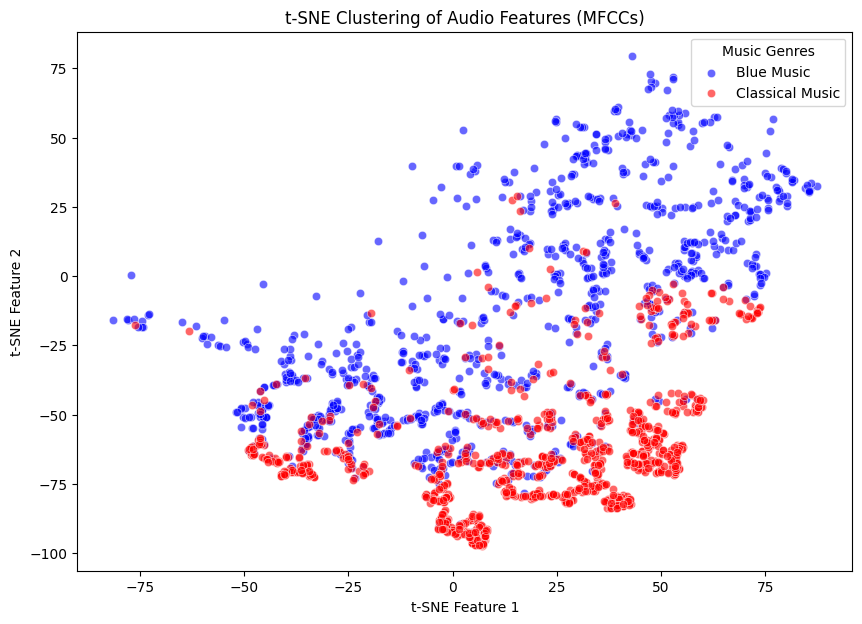

In [34]:
# 2. Define colors and labels
colors = ['blue', 'red']
class_labels = ['Blue Music', 'Classical Music']

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111)

# 3. Loop to plot each class separately for the legend
for i in range(len(colors)):
    # Mask to select only the points belonging to class 'i'
    mask = (y == i)

    ax.scatter(
        X_tsne_2[mask, 0],
        X_tsne_2[mask, 1],
        c=colors[i],
        label=class_labels[i],
        alpha=0.6,
        edgecolors='w', # White edge makes points pop on t-SNE
        linewidth=0.5
    )

# 4. Final Formatting
ax.set_xlabel('t-SNE Feature 1')
ax.set_ylabel('t-SNE Feature 2')
ax.set_title('t-SNE Clustering of Audio Features (MFCCs)')
ax.legend(title="Music Genres", loc='upper right')

plt.show()